In [1]:
##########################################
# Añadir esto al principio de cada ipynb #
##########################################
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/_UOC/tfm-solar-forecasting/')

# Verifica que existan las carpetas esperadas
!ls
# Debes ver 'src' y 'config'

Mounted at /content/drive
checkpoints  data  lightning_logs  README.md	     results
config	     doc   notebooks	   requirements.txt  src


In [2]:
# ============================================================================
# CELDA COLAB — Ejecutar PRIMERO en Google Colab (saltar en local)
# ============================================================================
# 1. Monta Google Drive:
#    from google.colab import drive; drive.mount('/content/drive')
# 2. Navega al repo:
#    import os; os.chdir('/content/drive/MyDrive/_MCD/TFM/MUDS-TFM/tfm-solar-forecasting/')
# 3. Ejecuta esta celda → instala dependencias automáticamente si está en Colab
#
# PRERREQUISITO: ejecutar 00_eda_preprocessing.ipynb para crear data/processed/
# ============================================================================

import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    import subprocess
    print('Colab detectado — instalando dependencias...')
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install',
         'pvlib',
         'pytorch-forecasting>=1.1.0',
         'lightning',
         '--quiet'],
        check=True
    )
    print('✓ Dependencias instaladas')
else:
    print('Entorno local — sin instalaciones adicionales')

Colab detectado — instalando dependencias...
✓ Dependencias instaladas


In [3]:
# ============================================================================
# BASELINE CON TFT (Temporal Fusion Transformer) - FORECASTING SOLAR
# Dataset: 14 plantas fotovoltaicas, año 2025
# ============================================================================

import sys
# Añadir src/ al path buscando la raíz del repo desde el directorio actual.
# En Google Colab: montar Drive y hacer os.chdir() al repo ANTES de ejecutar.
#   from google.colab import drive; drive.mount('/content/drive')
#   import os; os.chdir('/content/drive/MyDrive/.../tfm-solar-forecasting/')
import pathlib as _pl
_root = next(
    (p for p in [_pl.Path.cwd(), *_pl.Path.cwd().parents]
     if (p / 'src').is_dir() and (p / 'data' / 'processed').is_dir()),
    None
)
if _root is None:
    raise RuntimeError(
        f"No se encontró src/. cwd={_pl.Path.cwd()}\n"
        "En Colab: monta Drive y ejecuta os.chdir() al repo antes de %run."
    )
sys.path.insert(0, str(_root / 'src'))
del _pl, _root
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import torch
import warnings
warnings.filterwarnings('ignore')

# Módulos custom
from data_processing import SolarDataProcessor
from tft_data_loader import TFTDatasetCreator
from tft_model import TFTForecaster
from evaluation import ForecastEvaluator

# Módulo de armonización ex1_compare
from ex1_compare import PLANTAS, SMOKE_TEST, SMOKE_MAX_ROWS, DEVICE, DATA_DIR, RESULTS_DIR, CHECKPOINTS_DIR
from ex1_compare import plot_diagnostic, plot_timeseries, plot_model_comparison
from ex1_compare import ResultsManager

# Configuración
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
pd.set_option('display.max_columns', None)

device = DEVICE
print(f"Usando device: {device}")

%matplotlib inline

# Inicializar gestor de resultados
rm = ResultsManager('tft', results_dir=RESULTS_DIR, checkpoints_dir=CHECKPOINTS_DIR)

print("="*80)
print("EXPERIMENTO 1c: BASELINE CON TFT (Temporal Fusion Transformer)")
print(f"Plantas: {PLANTAS}")
print(f"Smoke test: {SMOKE_TEST}")
print("="*80)

[ex1] Entorno: Google Colab | Device: cuda (Tesla T4)
Usando device: cuda
ResultsManager [tft]
  Figuras:     /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/tft
  Metricas:    /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/metrics
  Checkpoints: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/checkpoints/ex1_compare/tft
EXPERIMENTO 1c: BASELINE CON TFT (Temporal Fusion Transformer)
Plantas: ['UPGARNACHA', 'FVARENA', 'NBALBOA', 'RODRI', 'UFMULA', 'TALASOL']
Smoke test: False


In [4]:
# ============================================================================
# KEEP-ALIVE COLAB — Evita desconexión por inactividad
# Ejecutar esta celda UNA VEZ al inicio del entrenamiento (solo en Colab)
# ============================================================================
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from IPython.display import display, Javascript
    display(Javascript("""
    function ClickConnect(){
        console.log("Keep-alive: click en 'Conectar'");
        document.querySelector("colab-toolbar-button#connect")?.click();
    }
    // Haz clic cada 60 segundos para mantener la sesión activa
    var interval = setInterval(ClickConnect, 60000);
    console.log("Keep-alive iniciado (interval id=" + interval + ")");
    """))
    print("✓ Keep-alive activado (click automático cada 60 s)")
    print("  Para detenerlo: ejecuta clearInterval(<id>) en la consola del navegador")
else:
    print("Entorno local — keep-alive no necesario")

<IPython.core.display.Javascript object>

✓ Keep-alive activado (click automático cada 60 s)
  Para detenerlo: ejecuta clearInterval(<id>) en la consola del navegador


In [5]:
# ============================================================================
# 1. CARGAR DATOS PROCESADOS
# ============================================================================

print("\n[1/6] Cargando datos procesados...")

df_train = pd.read_csv(DATA_DIR / 'train.csv')
df_val   = pd.read_csv(DATA_DIR / 'val.csv')
df_test  = pd.read_csv(DATA_DIR / 'test.csv')

print(f"✓ Datos cargados")
print(f"  Train: {len(df_train):,} registros")
print(f"  Val:   {len(df_val):,} registros")
print(f"  Test:  {len(df_test):,} registros")

# Excluir horas inválidas del entrenamiento (curtailment + huecos largos)
# TFT no usa ventanas deslizantes como LSTM, así que filtramos directamente.
# El test NO se filtra aquí: se filtra en la evaluación de métricas.
_HAS_VALID = 'valid_data' in df_train.columns
if _HAS_VALID:
    n_inv_tr = (~df_train['valid_data'].fillna(True).astype(bool)).sum()
    n_inv_va = (~df_val['valid_data'].fillna(True).astype(bool)).sum()
    df_train = df_train[df_train['valid_data'].fillna(True).astype(bool)].reset_index(drop=True)
    df_val   = df_val[df_val['valid_data'].fillna(True).astype(bool)].reset_index(drop=True)
    if n_inv_tr + n_inv_va > 0:
        print(f"  ⚠ Excluidas: {n_inv_tr} filas train + {n_inv_va} val (valid_data=False)")

plantas = sorted(df_train['planta_nombre'].unique())
print(f"\nPlantas: {len(plantas)}")

df_train['zona_climatica'] = df_train['zona_climatica'].astype('category').cat.codes
df_val['zona_climatica']   = df_val['zona_climatica'].astype('category').cat.codes
df_test['zona_climatica']  = df_test['zona_climatica'].astype('category').cat.codes



[1/6] Cargando datos procesados...
✓ Datos cargados
  Train: 50,917 registros
  Val:   6,780 registros
  Test:  8,922 registros
  ⚠ Excluidas: 254 filas train + 25 val (valid_data=False)

Plantas: 6


In [6]:
# ============================================================================
# PASO 2: Codificar solo lo necesario
# ============================================================================

print("\nCodificando variables categóricas...")

# Estación
estacion_map = {'Invierno': 0, 'Primavera': 1, 'Verano': 2, 'Otoño': 3}
df_train['estacion_encoded'] = df_train['estacion'].map(estacion_map)
df_val['estacion_encoded'] = df_val['estacion'].map(estacion_map)
df_test['estacion_encoded'] = df_test['estacion'].map(estacion_map)

# Zona climática
from sklearn.preprocessing import LabelEncoder
le_zona = LabelEncoder()
df_train['zona_climatica_encoded'] = le_zona.fit_transform(df_train['zona_climatica'])
df_val['zona_climatica_encoded'] = le_zona.transform(df_val['zona_climatica'])
df_test['zona_climatica_encoded'] = le_zona.transform(df_test['zona_climatica'])

# Seguimiento
df_train['seguimiento_encoded'] = df_train['seguimiento'].astype(int)
df_val['seguimiento_encoded'] = df_val['seguimiento'].astype(int)
df_test['seguimiento_encoded'] = df_test['seguimiento'].astype(int)

print("✓ Variables categóricas codificadas")


Codificando variables categóricas...
✓ Variables categóricas codificadas


In [7]:
# ============================================================================
# 2. CONFIGURACIÓN - OPTIMIZADA PARA CPU
# ============================================================================

print("\n[2/6] Configuración optimizada para CPU...")

# Features conocidas futuras
TIME_VARYING_KNOWN_REALS = [
    'hora',
    'dia_semana',
    'mes',
    #'dia_año',
    'elevacion_solar',
    'es_dia',
    #'azimut_solar',
    'estacion_encoded'
]


# Features desconocidas futuras
TIME_VARYING_UNKNOWN_REALS = [
    'global_tilted_irradiance',  # Reducido: solo las más importantes
    'cloud_cover',
    'temperature_2m'
]

#TIME_VARYING_UNKNOWN_REALS += ['produccion_lag1', 'produccion_lag24']

STATIC_REALS = [
    'instalada_mw',
    'zona_climatica_encoded',
    'seguimiento_encoded'
]

print(f"Features conocidas: {len(TIME_VARYING_KNOWN_REALS)}")
print(f"Features desconocidas: {len(TIME_VARYING_UNKNOWN_REALS)}")
print(f"Features estaticas: {len(STATIC_REALS)}")

# Parámetros optimizados para CPU
PARAMS = {
    'max_encoder_length': 48,      # 1 semana
    'max_prediction_length': 1,     # 1 hora
    'hidden_size': 64,              # Reducido para CPU
    'attention_head_size': 4,       # Reducido para CPU
    'dropout': 0.1,
    'hidden_continuous_size': 16,    # Reducido para CPU
    'learning_rate': 0.001,         # Aumentado para convergencia rápida
    'batch_size': 64,              # Aumentado para CPU
    'max_epochs': 40,               # Reducido
    'patience': 10                   # Reducido
}

print(f"\nParámetros TFT (CPU):")
for k, v in PARAMS.items():
    print(f"  {k}: {v}")

print(f"\n⏱️  Tiempo estimado: ~8-12 min por planta (total ~1.5 horas)")


[2/6] Configuración optimizada para CPU...
Features conocidas: 6
Features desconocidas: 3
Features estaticas: 3

Parámetros TFT (CPU):
  max_encoder_length: 48
  max_prediction_length: 1
  hidden_size: 64
  attention_head_size: 4
  dropout: 0.1
  hidden_continuous_size: 16
  learning_rate: 0.001
  batch_size: 64
  max_epochs: 40
  patience: 10

⏱️  Tiempo estimado: ~8-12 min por planta (total ~1.5 horas)


In [8]:
# ============================================================================
# 3. ENTRENAMIENTO — con checkpoint por planta (resume seguro)
# ============================================================================
# Si Colab se reinicia: vuelve a ejecutar desde la celda 1. Las plantas que
# ya terminarom se cargan desde disco y se saltan; solo se entrenan las pendientes.
# ============================================================================

import traceback
import time
import pickle
import json

print(f"\n[3/6] Entrenamiento de modelos TFT")
print("="*80)

_HAS_VALID = 'valid_data' in df_test.columns

dataset_creator = TFTDatasetCreator(
    max_encoder_length=PARAMS['max_encoder_length'],
    max_prediction_length=PARAMS['max_prediction_length'],
    target_col='produccion'
)

models = {}
results_all = []
interpretations = {}
training_times = {}

plantas_p = PLANTAS

# Carpeta de checkpoints por planta (dentro de ckpt_dir del experimento)
ckpt_plant_dir = Path(rm.ckpt_dir)
ckpt_plant_dir.mkdir(parents=True, exist_ok=True)

def _plant_pred_path(planta):
    return ckpt_plant_dir / f'predictions_{planta}.csv'

def _plant_interp_path(planta):
    return ckpt_plant_dir / f'interp_{planta}.pkl'

def _plant_meta_path(planta):
    return ckpt_plant_dir / f'meta_{planta}.json'

print(f"\nCheckpoints por planta en: {ckpt_plant_dir}")
print(f"Iterando por plantas ({len(plantas_p)} en total)...")

# ──────────────────────────────────────────────────────────────────────────────
# Loop por plantas
# ──────────────────────────────────────────────────────────────────────────────
for i, planta in enumerate(plantas_p, 1):
    print(f"\n{'='*80}")
    print(f"PLANTA {i}/{len(plantas_p)}: {planta}")

    # ------------------------------------------------------------------
    # RESUME: si ya existe checkpoint, cargar y saltar entrenamiento
    # ------------------------------------------------------------------
    if _plant_pred_path(planta).exists():
        print(f"  ✓ Checkpoint encontrado — cargando desde disco (skip entrenamiento)")
        df_pred = pd.read_csv(_plant_pred_path(planta))
        if 'timestamp' in df_pred.columns:
            df_pred['timestamp'] = pd.to_datetime(df_pred['timestamp'])
        results_all.append(df_pred)

        if _plant_interp_path(planta).exists():
            with open(_plant_interp_path(planta), 'rb') as f:
                interpretations[planta] = pickle.load(f)
            print(f"  ✓ Interpretabilidad cargada")

        if _plant_meta_path(planta).exists():
            try:
                with open(_plant_meta_path(planta), 'r') as f:
                    meta = json.load(f)
                training_times[planta] = meta.get('training_time_s', float('nan'))
                print(f"  ✓ Meta cargada (tiempo: {training_times[planta]/60:.1f} min)")
            except (json.JSONDecodeError, ValueError):
                # Fichero corrupto (escritura interrumpida en sesión anterior)
                training_times[planta] = float('nan')
                print(f"  ⚠ meta JSON corrupto — tiempo desconocido (no afecta al entrenamiento)")
        continue

    # ------------------------------------------------------------------
    # ENTRENAMIENTO NORMAL
    # ------------------------------------------------------------------
    planta_info = df_train[df_train['planta_nombre'] == planta].iloc[0]
    print(f"Zona: {planta_info['zona_climatica']}  |  Capacidad: {planta_info['instalada_mw']:.1f} MW")
    print('='*80)

    start_time = time.time()

    try:
        # ============================================================
        # 1. CREAR DATASETS
        # ============================================================
        train_dataset, val_dataset, test_dataset = dataset_creator.create_train_val_test(
            df_train, df_val, df_test,
            planta,
            time_varying_known_reals=TIME_VARYING_KNOWN_REALS,
            time_varying_unknown_reals=TIME_VARYING_UNKNOWN_REALS,
            static_reals=STATIC_REALS
        )

        # ============================================================
        # 2. ENTRENAR MODELO
        # ============================================================
        forecaster = TFTForecaster(
            hidden_size=PARAMS['hidden_size'],
            attention_head_size=PARAMS['attention_head_size'],
            dropout=PARAMS['dropout'],
            hidden_continuous_size=PARAMS['hidden_continuous_size'],
            learning_rate=PARAMS['learning_rate']
        )

        forecaster.fit(
            train_dataset,
            val_dataset,
            planta_nombre=planta,
            max_epochs=PARAMS['max_epochs'],
            patience=PARAMS['patience'],
            batch_size=PARAMS['batch_size'],
            verbose=True
        )

        # ============================================================
        # 3. PREDECIR
        # ============================================================
        df_pred = forecaster.predict(
            test_dataset,
            batch_size=PARAMS['batch_size']
        )

        # ============================================================
        # ALINEACIÓN DE TIMESTAMPS
        # ============================================================
        df_test_planta = df_test[df_test['planta_nombre'] == planta].copy().reset_index(drop=True)

        n_pred = len(df_pred)
        if len(df_test_planta) >= n_pred:
            df_test_aligned = df_test_planta.tail(n_pred).reset_index(drop=True)
        else:
            min_len = min(len(df_test_planta), n_pred)
            df_test_aligned = df_test_planta.tail(min_len).reset_index(drop=True)
            df_pred = df_pred.tail(min_len).reset_index(drop=True)

        df_pred['timestamp'] = pd.to_datetime(df_test_aligned['timestamp_utc'].values)
        if df_pred['timestamp'].dt.tz is not None:
            df_pred['timestamp'] = df_pred['timestamp'].dt.tz_localize(None)

        df_pred['hora'] = df_test_aligned['hora'].values
        df_pred['mes'] = df_test_aligned['mes'].values
        df_pred['cloud_cover'] = df_test_aligned['cloud_cover'].values
        df_pred['estacion'] = df_test_aligned['estacion'].values
        df_pred['zona_climatica'] = df_test_aligned['zona_climatica'].values

        if _HAS_VALID and 'valid_data' in df_test_aligned.columns:
            df_pred['valid_data'] = df_test_aligned['valid_data'].values

        if 'idx' in df_pred.columns:
            df_pred = df_pred.drop(columns=['idx'])

        # ============================================================
        # DIAGNÓSTICO BÁSICO
        # ============================================================
        print(f"\nDiagnostico {planta}:")
        print(f"  Predicciones: {len(df_pred)}")
        print(f"  y_true - mean: {df_pred['y_true'].mean():.2f}, max: {df_pred['y_true'].max():.2f}")
        print(f"  y_pred - mean: {df_pred['y_pred'].mean():.2f}, max: {df_pred['y_pred'].max():.2f}")
        ratio = df_pred['y_pred'].mean() / df_pred['y_true'].mean() if df_pred['y_true'].mean() > 0 else 0
        print(f"  Ratio pred/true: {ratio:.4f}")

        # Guardar checkpoint del modelo
        if hasattr(forecaster, 'model') and forecaster.model is not None:
            rm.save_checkpoint(forecaster.model, planta)

        # ============================================================
        # 4. MÉTRICAS (solo horas válidas)
        # ============================================================
        if _HAS_VALID and 'valid_data' in df_pred.columns:
            df_pred_eval = df_pred[df_pred['valid_data'].fillna(True).astype(bool)]
            n_excl = len(df_pred) - len(df_pred_eval)
            if n_excl > 0:
                print(f"  ⚠ {n_excl} horas excluidas de métricas test (valid_data=False)")
        else:
            df_pred_eval = df_pred

        elapsed = time.time() - start_time
        training_times[planta] = elapsed

        metrics = ForecastEvaluator.calculate_metrics(
            df_pred_eval['y_true'].values,
            df_pred_eval['y_pred'].values,
            planta_nombre=planta
        )

        print(f"\nMETRICAS EN TEST:")
        print(f"  MAE:  {metrics['MAE']:.4f}")
        print(f"  RMSE: {metrics['RMSE']:.4f}")
        print(f"  MAPE: {metrics['MAPE']:.2f} %")
        print(f"  R2:   {metrics['R2']:.4f}")
        print(f"  Tiempo: {elapsed/60:.1f} min ({elapsed:.0f} s)")

        # ============================================================
        # 5. INTERPRETABILIDAD (Variable Selection Weights)
        # ============================================================
        try:
            test_dl = test_dataset.to_dataloader(
                train=False, batch_size=PARAMS['batch_size'],
                num_workers=0, pin_memory=False
            )
            # pytorch-forecasting >=1.1.0 devuelve named tuple Prediction,
            # no una tupla (output, x) → acceder por atributo
            pred_result = forecaster.model.predict(
                test_dl, mode="raw", return_x=True
            )
            if hasattr(pred_result, 'prediction'):
                raw_preds = pred_result.prediction
            else:
                raw_preds = pred_result[0]
            interp = forecaster.model.interpret_output(raw_preds, reduction="sum")
            interpretations[planta] = {k: v.detach().cpu() for k, v in interp.items()}
            print(f"  Interpretabilidad extraida")
        except Exception as e:
            print(f"  Interpretabilidad no disponible: {e}")

        # ============================================================
        # GUARDAR CHECKPOINT POR PLANTA (permite resume si Colab cae)
        # ============================================================
        df_pred.to_csv(_plant_pred_path(planta), index=False)

        if planta in interpretations:
            with open(_plant_interp_path(planta), 'wb') as f:
                pickle.dump(interpretations[planta], f)

        with open(_plant_meta_path(planta), 'w') as f:
            # float() convierte numpy.float32 a Python float (JSON serializable)
            json.dump({
                'training_time_s': float(elapsed),
                'MAE': float(metrics['MAE']),
                'R2':  float(metrics['R2']),
            }, f)

        results_all.append(df_pred)
        print(f"  ✓ Checkpoint guardado → {_plant_pred_path(planta).name}")

    except Exception as e:
        print(f"Error con {planta}: {e}")
        traceback.print_exc()
        continue

# ──────────────────────────────────────────────────────────────────────────────
# Consolidar y guardar resultado global
# ──────────────────────────────────────────────────────────────────────────────
if len(results_all) == 0:
    raise ValueError("No se generaron predicciones para ninguna planta")

df_results = pd.concat(results_all, ignore_index=True)
rm.save_predictions(df_results)
print(f"\n✓ Predicciones globales guardadas ({len(df_results):,} registros)")


[3/6] Entrenamiento de modelos TFT

Checkpoints por planta en: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/checkpoints/ex1_compare/tft
Iterando por plantas (6 en total)...

PLANTA 1/6: UPGARNACHA
  ✓ Checkpoint encontrado — cargando desde disco (skip entrenamiento)
  ✓ Interpretabilidad cargada
  ⚠ meta JSON corrupto — tiempo desconocido (no afecta al entrenamiento)

PLANTA 2/6: FVARENA
  ✓ Checkpoint encontrado — cargando desde disco (skip entrenamiento)
  ✓ Interpretabilidad cargada
  ⚠ meta JSON corrupto — tiempo desconocido (no afecta al entrenamiento)

PLANTA 3/6: NBALBOA
  ✓ Checkpoint encontrado — cargando desde disco (skip entrenamiento)
  ✓ Interpretabilidad cargada
  ✓ Meta cargada (tiempo: 44.1 min)

PLANTA 4/6: RODRI
  ✓ Checkpoint encontrado — cargando desde disco (skip entrenamiento)
  ✓ Interpretabilidad cargada
  ✓ Meta cargada (tiempo: 23.6 min)

PLANTA 5/6: UFMULA
Zona: 2  |  Capacidad: 493.7 MW

Creando datasets TFT para UFMULA...
  Train: 8,899 secuencias
  V

INFO: GPU available: True (cuda), used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


  Modelo TFT: 299,879 parametros


Output()

INFO: `Trainer.fit` stopped: `max_epochs=40` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=40` reached.


...

Output()

  Val:   1,033 secuencias
  Test:  1,415 secuencias

Entrenando TFT para TALASOL...
  Modelo TFT: 299,879 parametros


✓ Entrenamiento completado
  Mejor val_loss: 22.3718

Generando predicciones...
  Predicciones procesadas: 1415
✓ 1,415 predicciones generadas

Diagnostico TALASOL:
  Predicciones: 1415
  y_true - mean: 108.52, max: 726.00
  y_pred - mean: 102.53, max: 788.73
  Ratio pred/true: 0.9448


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

  Checkpoint guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/checkpoints/ex1_compare/tft/TALASOL.ckpt

METRICAS EN TEST:
  MAE:  28.2554
  RMSE: 62.8806
  MAPE: 79.30 %
  R2:   0.8907
  Tiempo: 35.2 min (2115 s)
  Interpretabilidad extraida
  ✓ Checkpoint guardado → predictions_TALASOL.csv
  Predicciones guardadas: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/metrics/tft_predictions.csv

✓ Predicciones globales guardadas (8,490 registros)


In [9]:
# ============================================================================
# 4. MÉTRICAS AGREGADAS
# ============================================================================

print(f"\n[4/6] Evaluación agregada")
print("="*80)

_HAS_VALID = 'valid_data' in df_results.columns
metrics_summary = []

for planta in df_results['planta_nombre'].unique():
    df_planta = df_results[df_results['planta_nombre'] == planta]
    zona = df_planta['zona_climatica'].iloc[0]

    # Filtrar horas no válidas antes de calcular métricas
    if _HAS_VALID:
        df_eval = df_planta[df_planta['valid_data'].fillna(True).astype(bool)]
    else:
        df_eval = df_planta

    m = ForecastEvaluator.calculate_metrics(
        df_eval['y_true'].values,
        df_eval['y_pred'].values,
        planta_nombre=planta
    )
    m['zona_climatica'] = zona
    if 'training_time_s' in df_planta.columns or planta in training_times:
        m['training_time_s'] = training_times.get(planta, np.nan)
    metrics_summary.append(m)

df_metrics_tft = pd.DataFrame(metrics_summary)
df_metrics_tft = df_metrics_tft.sort_values(['zona_climatica', 'MAE'])

print("\nMETRICAS POR PLANTA:")
cols_show = ['planta', 'zona_climatica', 'MAE', 'RMSE', 'MAPE', 'R2']
if 'training_time_s' in df_metrics_tft.columns:
    cols_show.append('training_time_s')
print(df_metrics_tft[cols_show].to_string(index=False))

# Guardar vía ResultsManager
rm.save_metrics(df_metrics_tft)

# Promedio global
print(f"\nPROMEDIO GLOBAL ({len(df_metrics_tft)} plantas):")
print(f"  MAE:  {df_metrics_tft['MAE'].mean():.4f} +/- {df_metrics_tft['MAE'].std():.4f}")
print(f"  RMSE: {df_metrics_tft['RMSE'].mean():.4f} +/- {df_metrics_tft['RMSE'].std():.4f}")
print(f"  R2:   {df_metrics_tft['R2'].mean():.4f} +/- {df_metrics_tft['R2'].std():.4f}")
if 'training_time_s' in df_metrics_tft.columns:
    print(f"  Tiempo total: {df_metrics_tft['training_time_s'].sum():.1f} s  "
          f"({df_metrics_tft['training_time_s'].sum()/60:.1f} min)")



[4/6] Evaluación agregada

METRICAS POR PLANTA:
    planta  zona_climatica       MAE       RMSE       MAPE       R2  training_time_s
   FVARENA               0 11.941518  26.448563  79.621197 0.824338              NaN
   TALASOL               0 28.255438  62.880554  79.297982 0.890730      2114.571360
   NBALBOA               0 42.783164 100.935327 167.579511 0.867175      2648.176143
UPGARNACHA               1 13.819629  31.355907  56.043284 0.851622              NaN
     RODRI               2 14.484742  32.146330  98.003174 0.940495      1416.342223
    UFMULA               2 49.414064 108.896436  69.324410 0.924624      2317.561744
  Metricas guardadas: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/metrics/tft_metrics_summary.csv

PROMEDIO GLOBAL (6 plantas):
  MAE:  26.7831 +/- 16.1858
  RMSE: 60.4439 +/- 36.8665
  R2:   0.8832 +/- 0.0442
  Tiempo total: 8496.7 s  (141.6 min)



[5/6] Comparación entre modelos disponibles
  Solo hay metricas de tft — mostrando resultado individual.
  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/tft/comparison_all_models.png


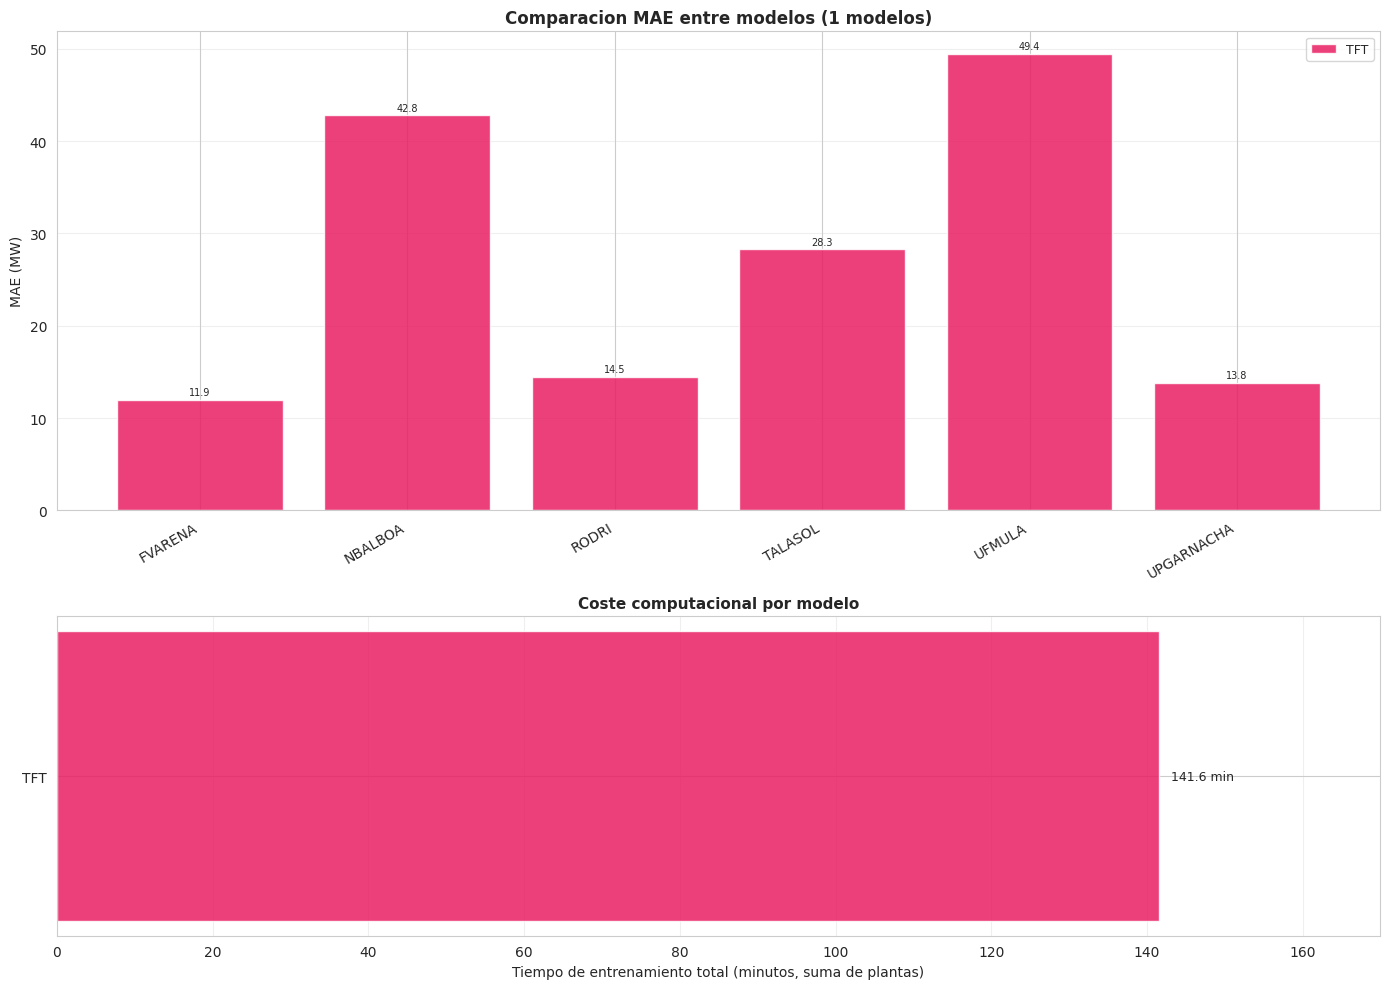

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/metrics/comparison_all_models.csv


In [10]:
# ============================================================================
# 5. COMPARACIÓN ENTRE MODELOS
# ============================================================================

print(f"\n[5/6] Comparación entre modelos disponibles")
print("="*80)

plot_model_comparison(df_metrics_tft, 'tft', save_dir=rm.figures_dir)

In [11]:
# ============================================================================
# 6. VISUALIZACIONES
# ============================================================================

print(f"\n{'='*80}")
print("GENERANDO VISUALIZACIONES")
print(f"{'='*80}")

for planta in df_results['planta_nombre'].unique():
    df_planta = df_results[df_results['planta_nombre'] == planta]
    print(f"\n  Graficando {planta}...")

    # Plot diagnóstico 4-panel
    plot_diagnostic(df_planta, planta, 'tft', save_dir=rm.figures_dir)

    # Serie temporal extendida (14 días)
    plot_timeseries(df_planta, planta, 'tft', save_dir=rm.figures_dir, days=14)

print(f"\nVisualizaciones guardadas en {rm.figures_dir}")

Output hidden; open in https://colab.research.google.com to view.


INTERPRETABILIDAD TFT: IMPORTANCIA DE VARIABLES

Figura guardada: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/tft/tft_feature_importance.png


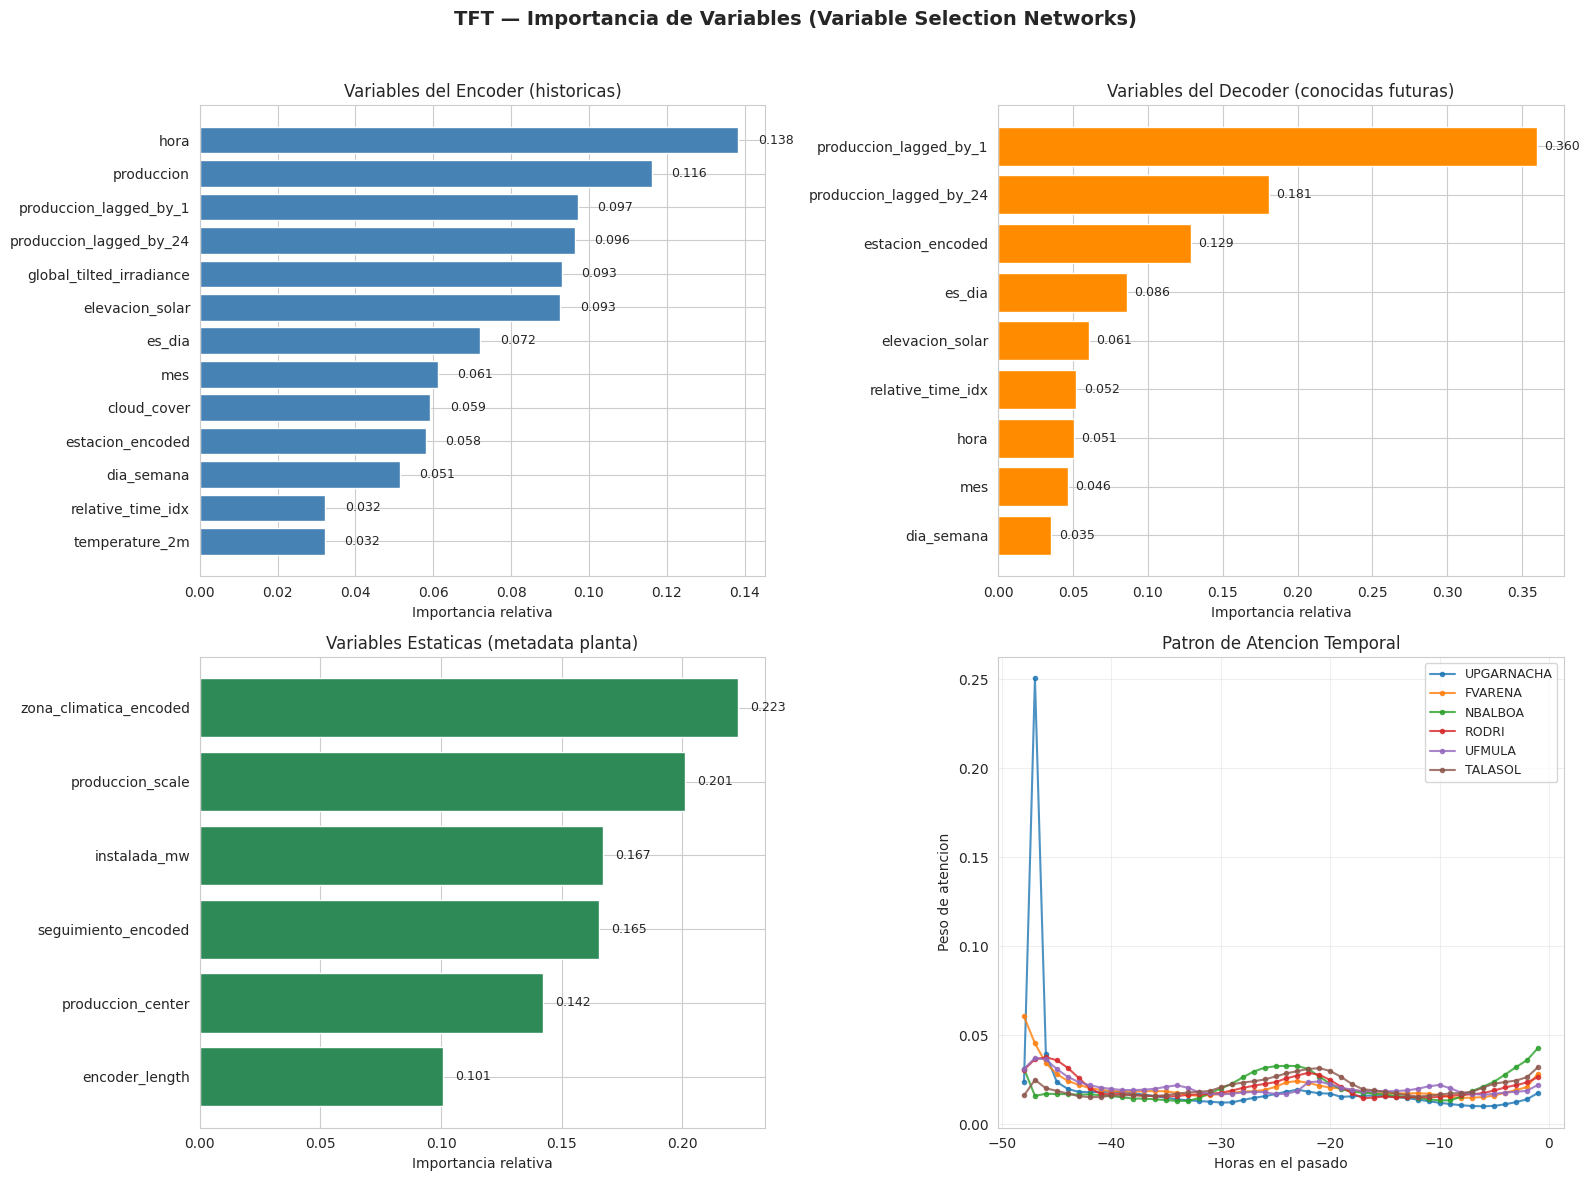


IMPORTANCIA DE VARIABLES POR PLANTA

--- ENCODER ---
planta                    FVARENA  NBALBOA   RODRI  TALASOL  UFMULA  UPGARNACHA   media
variable                                                                               
hora                       0.0212   0.1816  0.1446   0.3072  0.0200      0.1557  0.1384
produccion                 0.0296   0.1276  0.0729   0.0561  0.2947      0.1164  0.1162
produccion_lagged_by_1     0.0861   0.0523  0.1043   0.0934  0.1985      0.0482  0.0971
produccion_lagged_by_24    0.2895   0.0389  0.1031   0.0225  0.0297      0.0944  0.0964
global_tilted_irradiance   0.1374   0.1590  0.0381   0.0357  0.0625      0.1251  0.0930
elevacion_solar            0.1546   0.0569  0.0428   0.1316  0.1199      0.0501  0.0927
es_dia                     0.0215   0.0189  0.2124   0.0267  0.1119      0.0409  0.0721
mes                        0.0446   0.0607  0.0726   0.0428  0.0395      0.1064  0.0611
cloud_cover                0.0548   0.0168  0.0852   0.1058  0.033

In [12]:
# ============================================================================
# 7. INTERPRETABILIDAD — Importancia de Variables (Variable Selection Networks)
# ============================================================================

print(f"\n{'='*80}")
print("INTERPRETABILIDAD TFT: IMPORTANCIA DE VARIABLES")
print(f"{'='*80}")

if not interpretations:
    print("No hay datos de interpretabilidad disponibles.")
else:
    # Obtener nombres de variables del último modelo entrenado
    encoder_vars = list(forecaster.model.encoder_variables)
    decoder_vars = list(forecaster.model.decoder_variables)
    static_vars = list(forecaster.model.static_variables)

    # ------------------------------------------------------------------
    # Calcular importancia promedio normalizada por planta
    # ------------------------------------------------------------------
    importance_records = []

    for planta, interp in interpretations.items():
        # Encoder variable importance
        if 'encoder_variables' in interp:
            weights = interp['encoder_variables'].numpy()
            weights_norm = weights / weights.sum() if weights.sum() > 0 else weights
            for var, w in zip(encoder_vars, weights_norm):
                importance_records.append({
                    'planta': planta, 'tipo': 'encoder',
                    'variable': var, 'importancia': float(w)
                })

        # Decoder variable importance
        if 'decoder_variables' in interp:
            weights = interp['decoder_variables'].numpy()
            weights_norm = weights / weights.sum() if weights.sum() > 0 else weights
            for var, w in zip(decoder_vars, weights_norm):
                importance_records.append({
                    'planta': planta, 'tipo': 'decoder',
                    'variable': var, 'importancia': float(w)
                })

        # Static variable importance
        if 'static_variables' in interp:
            weights = interp['static_variables'].numpy()
            weights_norm = weights / weights.sum() if weights.sum() > 0 else weights
            for var, w in zip(static_vars, weights_norm):
                importance_records.append({
                    'planta': planta, 'tipo': 'static',
                    'variable': var, 'importancia': float(w)
                })

    df_importance = pd.DataFrame(importance_records)

    # Importancia promedio por variable (media entre plantas)
    df_avg = df_importance.groupby(['tipo', 'variable'])['importancia'].mean().reset_index()
    df_avg = df_avg.sort_values(['tipo', 'importancia'], ascending=[True, True])

    # ------------------------------------------------------------------
    # Figura de 4 paneles
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('TFT — Importancia de Variables (Variable Selection Networks)',
                 fontsize=14, fontweight='bold', y=0.98)

    # Panel 1: Encoder variables
    ax1 = axes[0, 0]
    df_enc = df_avg[df_avg['tipo'] == 'encoder'].sort_values('importancia')
    if len(df_enc) > 0:
        ax1.barh(df_enc['variable'], df_enc['importancia'], color='steelblue', edgecolor='white')
        ax1.set_xlabel('Importancia relativa')
        ax1.set_title('Variables del Encoder (historicas)')
        for i, (_, row) in enumerate(df_enc.iterrows()):
            ax1.text(row['importancia'] + 0.005, i, f"{row['importancia']:.3f}",
                     va='center', fontsize=9)

    # Panel 2: Decoder variables
    ax2 = axes[0, 1]
    df_dec = df_avg[df_avg['tipo'] == 'decoder'].sort_values('importancia')
    if len(df_dec) > 0:
        ax2.barh(df_dec['variable'], df_dec['importancia'], color='darkorange', edgecolor='white')
        ax2.set_xlabel('Importancia relativa')
        ax2.set_title('Variables del Decoder (conocidas futuras)')
        for i, (_, row) in enumerate(df_dec.iterrows()):
            ax2.text(row['importancia'] + 0.005, i, f"{row['importancia']:.3f}",
                     va='center', fontsize=9)

    # Panel 3: Static variables
    ax3 = axes[1, 0]
    df_stat = df_avg[df_avg['tipo'] == 'static'].sort_values('importancia')
    if len(df_stat) > 0:
        ax3.barh(df_stat['variable'], df_stat['importancia'], color='seagreen', edgecolor='white')
        ax3.set_xlabel('Importancia relativa')
        ax3.set_title('Variables Estaticas (metadata planta)')
        for i, (_, row) in enumerate(df_stat.iterrows()):
            ax3.text(row['importancia'] + 0.005, i, f"{row['importancia']:.3f}",
                     va='center', fontsize=9)

    # Panel 4: Attention pattern (temporal)
    ax4 = axes[1, 1]
    has_attention = False
    for planta, interp in interpretations.items():
        if 'attention' in interp:
            attn = interp['attention'].numpy()
            # Normalizar: attention shape = (encoder_length,)
            attn_norm = attn / attn.sum() if attn.sum() > 0 else attn
            hours_back = np.arange(-len(attn_norm), 0)
            ax4.plot(hours_back, attn_norm, marker='o', markersize=3,
                     label=planta, alpha=0.8)
            has_attention = True

    if has_attention:
        ax4.set_xlabel('Horas en el pasado')
        ax4.set_ylabel('Peso de atencion')
        ax4.set_title('Patron de Atencion Temporal')
        ax4.legend(fontsize=9)
        ax4.grid(True, alpha=0.3)
    else:
        ax4.text(0.5, 0.5, 'Atencion temporal\nno disponible',
                 ha='center', va='center', fontsize=12, transform=ax4.transAxes)
        ax4.set_title('Patron de Atencion Temporal')

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # Guardar figura
    fig_path = Path(rm.figures_dir) / 'tft_feature_importance.png'
    fig_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f"\nFigura guardada: {fig_path}")
    plt.show()

    # ------------------------------------------------------------------
    # Tabla numérica: importancia por planta y variable
    # ------------------------------------------------------------------
    print(f"\n{'='*80}")
    print("IMPORTANCIA DE VARIABLES POR PLANTA")
    print(f"{'='*80}")

    for tipo in ['encoder', 'decoder', 'static']:
        df_tipo = df_importance[df_importance['tipo'] == tipo]
        if len(df_tipo) == 0:
            continue
        df_pivot = df_tipo.pivot_table(
            index='variable', columns='planta',
            values='importancia', aggfunc='mean'
        )
        df_pivot['media'] = df_pivot.mean(axis=1)
        df_pivot = df_pivot.sort_values('media', ascending=False)
        print(f"\n--- {tipo.upper()} ---")
        print(df_pivot.round(4).to_string())

    # Guardar CSV
    csv_path = Path(rm.metrics_dir) / 'tft_feature_importance.csv'
    df_importance.to_csv(csv_path, index=False)
    print(f"\nCSV guardado: {csv_path}")

In [14]:
# ============================================================================
# 8. RESUMEN
# ============================================================================

print(f"\n{'='*80}")
print("EXPERIMENTO TFT COMPLETADO")
print(f"{'='*80}")

print(f"\nResultados TFT:")
print(f"  Plantas procesadas: {len(df_metrics_tft)}")
print(f"  MAE promedio: {df_metrics_tft['MAE'].mean():.4f} h equiv.")
print(f"  Mejor planta: {df_metrics_tft.iloc[0]['planta']} (MAE: {df_metrics_tft.iloc[0]['MAE']:.4f})")
print(f"  Interpretabilidad: {len(interpretations)} plantas con Variable Selection Weights")

print(f"\nArchivos generados en {rm.results_dir}:")
print(f"  Metricas:    {rm.metrics_dir}/")
print(f"  Figuras:     {rm.figures_dir}/")
print(f"  Checkpoints: {rm.ckpt_dir}/")
print(f"  Importancia: tft_feature_importance.png / .csv")

print("\nExperimento completado")
print("="*80)


EXPERIMENTO TFT COMPLETADO

Resultados TFT:
  Plantas procesadas: 6
  MAE promedio: 26.7831 h equiv.
  Mejor planta: FVARENA (MAE: 11.9415)
  Interpretabilidad: 6 plantas con Variable Selection Weights

Archivos generados en /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare:
  Metricas:    /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/metrics/
  Figuras:     /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/tft/
  Checkpoints: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/checkpoints/ex1_compare/tft/
  Importancia: tft_feature_importance.png / .csv

Experimento completado
